# pipekit-train — quickstart

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pipekit/blob/main/docs/notebooks/pipekit_train_quickstart.ipynb)

End-to-end MLP training on a synthetic 1-D regression task. This is the
minimal "Hello, training!" for `pipekit-train` v0.1 — it shows the four
pieces that compose into a working training run:

1. A **`TrainingDataset`** that yields `(input, target)` pairs.
2. A **`Loss`** Operator (`MSE` here).
3. A **model Operator** — wrap an `eqx.Module` in `EquinoxModelOp`.
4. A **`TrainingLoop`** that ties them together and calls
   `pipekit_train.adapters.equinox.run` under the hood.

`TrainingLoop.run()` returns `(trained_model_op, artifact)`. The
trained operator drops into any inference pipeline; the artifact
captures everything needed to reproduce the run.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pipekit-train[equinox] @ git+https://github.com/jejjohnson/pipekit@main#subdirectory=packages/pipekit-train",
            "pipekit @ git+https://github.com/jejjohnson/pipekit@main#subdirectory=packages/pipekit",
        ],
        check=True,
    )

In [2]:
import equinox as eqx
import jax
import matplotlib.pyplot as plt
import numpy as np
from pipekit_train import MSE, IterableDataset, JSONLWriter, TrainingLoop
from pipekit_train.adapters.equinox import EquinoxModelOp

In [3]:
# Reproducibility readout — version metadata for the committed outputs.
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p numpy,jax,equinox,optax,pipekit,pipekit_train",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.3
IPython version      : 9.10.0

numpy        : 2.4.4
jax          : 0.10.1
equinox      : 0.13.8
optax        : 0.2.8
pipekit      : 0.0.1
pipekit_train: 0.0.1

Compiler    : GCC 13.3.0
OS          : Linux
Release     : 6.18.5
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## 1. The synthetic task

`y = 2x + 1 + small noise` — small enough to converge in seconds.

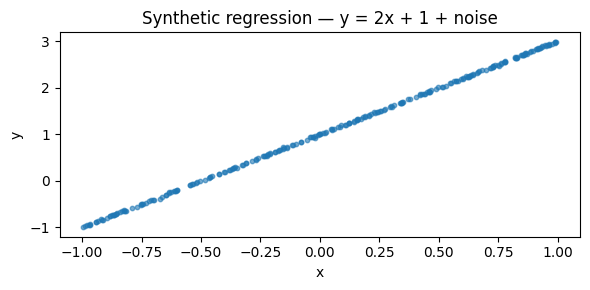

In [4]:
rng = np.random.default_rng(0)
n = 256
xs = rng.uniform(-1.0, 1.0, size=(n, 1)).astype(np.float32)
ys = (2.0 * xs + 1.0 + 0.01 * rng.standard_normal((n, 1))).astype(np.float32)

# Show the data.
plt.figure(figsize=(6, 3))
plt.scatter(xs[:, 0], ys[:, 0], s=10, alpha=0.6)
plt.title("Synthetic regression — y = 2x + 1 + noise")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

## 2. Wrap as a `TrainingDataset`

`IterableDataset` is the generic escape hatch. For datasets that
come from a `pipekit_cycle.ForwardModel`, use `SimulationDataset`
(covered in the cycle-handoff notebook). For catalog-backed sources,
`CatalogDataset` will ship in v0.1.x once `geocatalog` publishes.

In [5]:
pairs = list(zip(xs, ys, strict=True))
train_ds = IterableDataset(source=pairs, content_hash=f"synth-{n}")
val_ds = IterableDataset(source=pairs[: n // 4], content_hash=f"synth-val-{n // 4}")

## 3. The model

A tiny Equinox MLP. We wrap it in `EquinoxModelOp` so it's a
`pipekit.Operator` — same surface as every other pipekit primitive.
(When `pipekit-jax.JaxModelOp` ships, it's a drop-in replacement.)

In [6]:
mlp = eqx.nn.MLP(in_size=1, out_size=1, width_size=16, depth=2, key=jax.random.key(0))
model_op = EquinoxModelOp(mlp)

## 4. The training loop

`TrainingLoop` is a `pipekit.StatefulOperator`. We supply the
model, dataset, loss, and an optimiser config; the Equinox adapter
handles the rest. `MetricWriter` is optional — useful for
inspecting the loss curve afterwards.

In [7]:
writer = JSONLWriter(path="quickstart_metrics.jsonl", flush_every=1)

loop = TrainingLoop(
    model_op=model_op,
    dataset=train_ds,
    val_dataset=val_ds,
    loss=MSE(),
    optimizer_config={"name": "adam", "lr": 1e-2},
    max_steps=200,
    batch_size=16,
    eval_every_n_steps=50,
    log_every_n_steps=5,
    backend="equinox",
    metric_writer=writer,
    seed=42,
)

Run it. The first call compiles `train_step` via `eqx.filter_jit`
(a few hundred ms on CPU); subsequent steps reuse the compiled
function.

In [8]:
trained_op, artifact = loop.run()

print(f"Backend       : {artifact.backend_info['backend']}")
print(f"Final step    : {artifact.backend_info['final_step']}")
print(f"Final loss    : {artifact.backend_info['final_metrics']['mse']:.6f}")
print(f"Dataset hash  : {artifact.dataset_hash[:16]}…")
print(f"Total seconds : {artifact.backend_info['total_seconds']:.2f}")

Backend       : equinox
Final step    : 200
Final loss    : 0.001485
Dataset hash  : 1018572d5647a58a…
Total seconds : 1.67


## 5. Inspect the loss curve

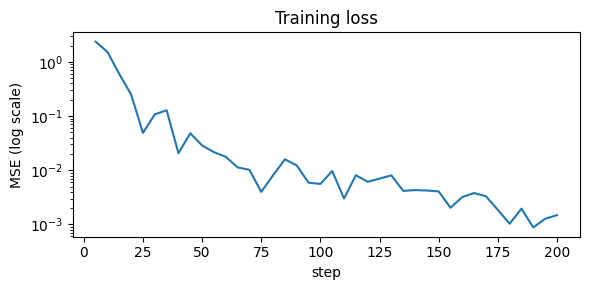

In [9]:
import json


with open("quickstart_metrics.jsonl") as f:
    records = [json.loads(line) for line in f]
steps = [r["step"] for r in records]
losses = [r["metrics"]["mse"] for r in records]

plt.figure(figsize=(6, 3))
plt.plot(steps, losses, lw=1.5)
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("MSE (log scale)")
plt.title("Training loss")
plt.tight_layout()
plt.show()

## 6. Use the trained model

`trained_op` is a `pipekit.Operator`. It composes into any
`Sequential`; calling it directly works too.

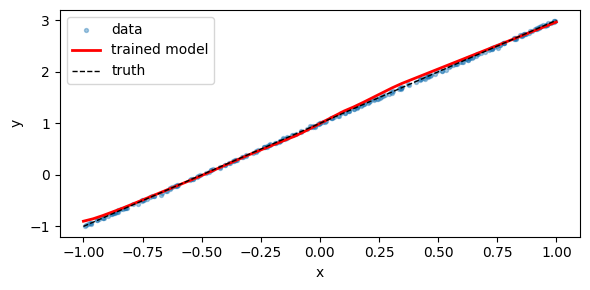

In [10]:
import jax.numpy as jnp


xs_test = jnp.linspace(-1, 1, 50).reshape(-1, 1)
preds = jax.vmap(trained_op)(xs_test)

plt.figure(figsize=(6, 3))
plt.scatter(xs[:, 0], ys[:, 0], s=8, alpha=0.4, label="data")
plt.plot(xs_test[:, 0], preds[:, 0], "r-", lw=2, label="trained model")
plt.plot(xs_test[:, 0], 2.0 * xs_test[:, 0] + 1.0, "k--", lw=1, label="truth")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

## 7. The artifact

`TrainingArtifact` is the reproducibility record. Save it to JSON
and the run is recoverable — pin a `ModelRegistry` and even the
weights round-trip.

In [11]:
artifact.save("quickstart_artifact.json")
yaml_len = len(artifact.training_pipeline_yaml)
print("Saved artifact.")
print(f"Contains: training_pipeline_yaml ({yaml_len} chars)")
print(f"          dataset_hash:    {artifact.dataset_hash[:16]}…")
print(f"          backend_info:    {list(artifact.backend_info.keys())}")
print(f"          deps_lock:       {len(artifact.deps_lock)} chars")

Saved artifact.
Contains: training_pipeline_yaml (606 chars)
          dataset_hash:    1018572d5647a58a…
          backend_info:    ['backend', 'jax_version', 'equinox_version', 'optax_version', 'devices', 'total_seconds', 'final_step', 'final_metrics']
          deps_lock:       3876 chars


### What's next

- **Cycle handoff** — train an emulator on a `pipekit_cycle.ForwardModel`
  and drop it back as a `NeuralForward` (see the companion notebook).
- **Custom callbacks** — implement any of the five
  `on_train_begin` / `on_step_end` / `on_epoch_end` / `on_eval_end`
  / `on_train_end` hooks; the adapter dispatches via `getattr`.
- **Experiment trackers** — `LogToExperiment(tracker=…)` bridges
  to any `pipekit_experiment.ExperimentTracker` (MLflow, W&B, …).

In [12]:
# Clean up the demo files.
import os


for path in ("quickstart_metrics.jsonl", "quickstart_artifact.json"):
    if os.path.exists(path):
        os.remove(path)